
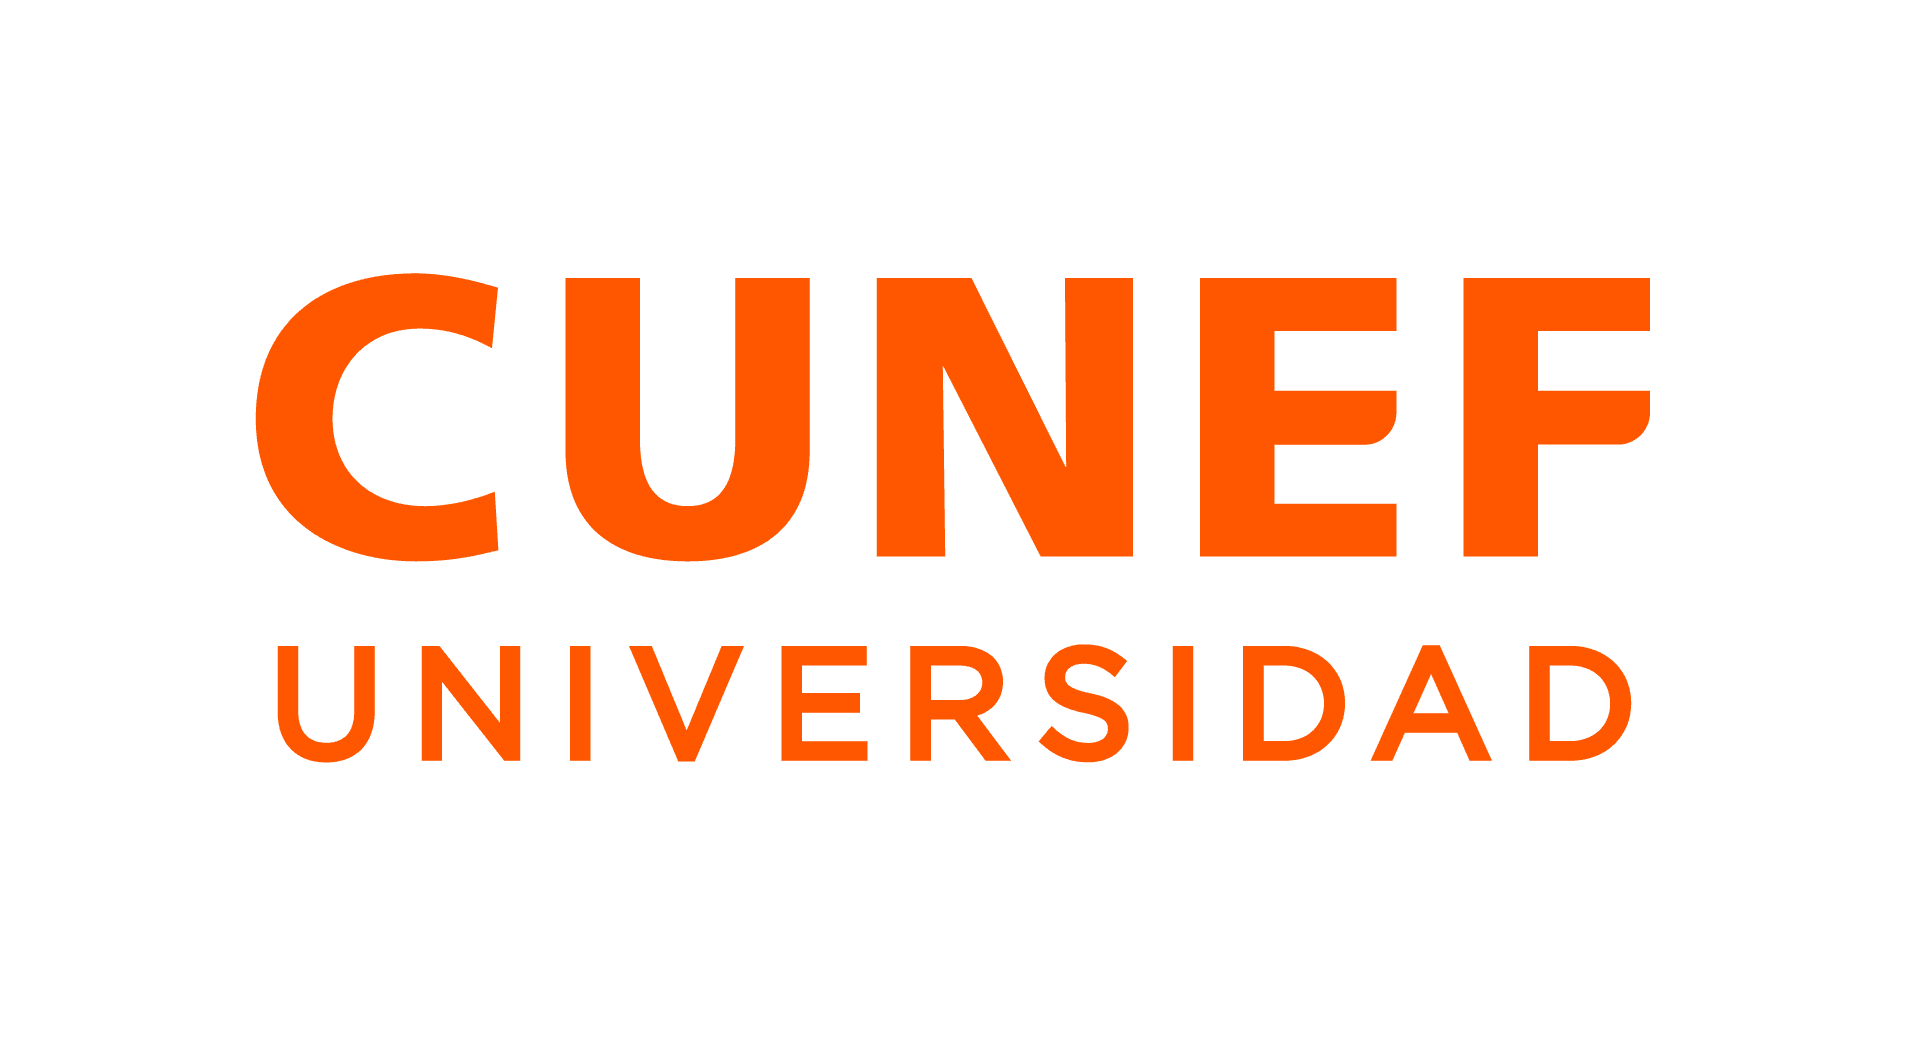

In [9]:
import base64
from IPython.display import HTML

with open("logo_cunef.png", "rb") as img_file:
    b64_image = base64.b64encode(img_file.read()).decode()

html_logo = f"""
<div style="text-align: center; margin: 20px;">
    <img src="data:image/png;base64,{b64_image}" width="300">
</div>
"""

HTML(html_logo)



<h1 align="center" style="color:#F26522;">
  Análisis Exploratorio de Datos (EDA) aplicado al Sector Hotelero en España
</h1>

<h3 align="center" style="color:#003A46;">
  Proyecto académico — Aprendizaje Automático  
  CUNEF Universidad
</h3>

---

# 1. Integrantes del equipo

| Apellidos | Nombre |
|----------|--------|
| **Baquero** | Mario |
| **Garrido** | Mirna |
| **Sánchez** | Joan |

---

# 2. Introducción

El turismo es uno de los motores fundamentales de la economía española y un eje estratégico en la competitividad del país. Dentro del sector, las **pernoctaciones hoteleras** constituyen uno de los indicadores más relevantes para medir la demanda turística y planificar decisiones tanto del sector público como del privado.

Como analistas de datos, nuestro cometido es analizar rigurosamente esta información para extraer conclusiones significativas, detectar patrones y preparar el terreno para futuros modelos predictivos basados en aprendizaje automático.

Este proyecto corresponde a la **Primera Entrega de la Evaluación Continua** de la asignatura *Aprendizaje Automático*, centrada en el **Análisis Exploratorio de Datos (EDA)** y en la correcta formulación del problema de negocio.

---

# 3. Problema de Negocio

##  Contexto empresarial


El Ministerio de Industria y Turismo, así como varias Consejerías de Turismo de las Comunidades Autónomas, han manifestado la necesidad de **disponer de un análisis cuantitativo actualizado y riguroso** sobre el comportamiento de la demanda hotelera en España.

España es uno de los países con mayor actividad turística del mundo. Para que el Gobierno pueda diseñar políticas públicas eficientes, taanto de promoción turística como de planificación de infraestructuras, servicios públicos y estrategias de sostenibilidad, es imprescindible explicarr:

- cómo evoluciona la **demanda de pernoctaciones**,  
- qué diferencias existen entre territorios,  
- cómo se comportan los **viajeros residentes vs no residentes**,  
- qué patrones de **estacionalidad** influyen en la presión turística (verano,primavera, otoño e invierno)  
- y qué indicadores deben monitorizarse para anticipar **picos de demanda**.

Los informes previos disponibles presentan dos limitaciones principales:

1. **Se basan en análisis agregados anuales o trimestrales**, insuficientes para comprender la dinámica real mensual.  
2. **No integran un enfoque orientado a aprendizaje automático**, que permita en fases posteriores desarrollar herramientas predictivas y sistemas de alerta temprana.

Por ello, el Gobierno solicita un **Análisis Exploratorio de Datos (EDA)** exhaustivo que siente las bases para un sistema técnico de apoyo a la decisión pública.


##  Problema identificado : 
> **Predecir el número de turistas del próximo verano para para cada provincia** 


El equipo de análisis ha sido encargado de:

> **Realizar un estudio detallado del comportamiento mensual del turismo hotelero en España, analizando patrones por comunidad autónoma, residencia, tipo de indicador y periodo, con el fin de extraer conclusiones útiles para la toma de decisiones y preparar el conjunto de datos para modelos predictivos futuros.**

El objetivo empresarial es disponer de un análisis sólido que permita:

- optimizar precios y capacidad,
- planificar campañas promocionales,
- orientar decisiones de inversión regional,
- y preparar modelos predictivos para futuros escenarios.

---

# 4. Origen y descripción del dataset

El dataset **`per.csv`** proviene de la **Encuesta de Ocupación en Establecimientos Hoteleros (EOH)** del **Instituto Nacional de Estadística (INE)**.  
La tabla original fue exportada y transformada a CSV manteniendo la estructura y los campos relevantes.

### Columnas principales del dataset

| **COLUMNA USADA** | **DESCRIPCIÓN** |
|-------------------|-----------------|
| Total_turismo_nacional | Indicador de nivel territorial (Total Nacional o Provincial). |
| Comunidades_ciudades_autonomas | Comunidad Autónoma o ciudad autónoma donde se ubica el establecimiento. |
| Provincias | Provincia específica del destino turístico. |
| Tipo_viajero | Clasificación según viajero o pernoctación. |
| Año | (int) |
| Mes | (int) |
| Temporada | Clasificación estacional (Verano, Otoño, Invierno, Primavera). |
| Turistas_totales | Cantidad de turistas o pernoctaciones (Variable objetivo). |
| Outliers_zscore | Indicador booleano (True/False) si el dato es considerado outlier. |

Este dataset permite estudiar el comportamiento de la demanda turística por región, por residencia y por temporalidad

---

# 5. Justificación del dataset

Elegimos trabajar con este dataset porque:

- refleja un **fenómeno real** y crítico para España,
- contiene estructura **temporal**, **territorial** y **segmentada**, ideal para un EDA profundo,
- es útil desde un punto de vista **empresarial** y estratégico,
- posee la granularidad necesaria para **modelos de regresión y clasificación** en futuras entregas,
- es coherente para formular un problema realista de aprendizaje automático.
- contiene variables de gran interés para la gestión pública.  


Este dataset también permite obtener insights muy relevantes para:

- cadenas hoteleras,
- aerolíneas,
- consultoras,

---

#  6. Planteamiento científico (Aprendizaje Automático)

Con el objetivo de que este trabajo sea escalable hacia un sistema predictivo, el estudio se formula bajo los principios del **Aprendizaje Automático**.


## A) Modelo de regresión supervisada  
**Objetivo:** Predecir el número de pernoctaciones mensuales por comunidad.

**Variables objetivo (target):**
- `Total` (filtrado a pernoctaciones totales)

**Variables explicativas:**
- comunidad autónoma  
- mes, año  
- residencia  
- tipo de indicador  
- lags temporales (t-1, t-12) en la segunda parte del proyecto  

---

##  B) Modelo de clasificación binaria (Bernoulli)  
**Objetivo:** Determinar si un mes será de *alta demanda* (`1`) o *baja demanda* (`0`) según el nivel de pernoctaciones.

Este enfoque será clave en la **segunda entrega**, donde aplicaremos **redes neuronales**.

---

#  7. Metodología del EDA (Primera Entrega)

En el notebook se desarrolla:

### 7.1 Análisis preliminar
- Inspección del dataset  
- Tipos de datos  
- Detección de nulos, inconsistencias y duplicados  

### 7.2 Limpieza y preprocesado
Para garantizar la calidad del análisis, se realizaron las siguientes intervenciones críticas en los datos:

- Tratamiento de "Total Nacional": Se identificó que el dataset original incluía filas agregadas bajo el concepto "Total Nacional". Tras entender mejor el dataset identificamos filas que correspondían al total nacional mensual, es decir, al conjunto de todas las provincias juntas, otras filas que se correspondían al total por comunidades agrupadas, y por ultimo el resto de filas siendo lo mayoritario del dataset que eran el total por cada provincia. Por esto, decidimos establecer Las columas de la siguiente manera:
      - En la columna Total Nacional se establece un booleano en el cual el 1 representa las filas sobre el total nacional mensual.
      - En la columna Comunidad_ciudad_autonoma decidimos establecer los valores de cada comunidad o ciudad autonoma, pero también añadir el valor "no aplica" cuando se estaría refiriendo al primer caso (total nacional mensual)
      - En la columna provincias, al igual que el anterior se añade el valor no "aplica" para referirnos en este caso al primer o segundo caso que hablamos antes(total nacional mensual o total por comunidades agrupadas).

- Reasignación de Ceuta y Melilla: En el dataset original, Ceuta y Melilla aparecían en ocasiones solo como "Comunidades" sin asignación provincial clara, o con formatos inconsistentes. Se imputaron como "Provincias" dentro de sus respectivas categorías para permitir una comparativa homogénea con el resto de provincias españolas. Ahora computan como unidades territoriales equivalentes al resto de provincias para el modelo.

- Conversión Temporal: Se transformaron las columnas Año y Mes en un objeto datetime para facilitar la visualización de series temporales y el ordenamiento cronológico correcto en los gráficos.

###  7.3 Detección de errores
- Nulos: Se verificó la existencia de nulos en la columna Provincias derivados de los agregados nacionales (corregido en el paso 7.2).
- Outliers: 
Un outlier (valor atípico) es una observación que se desvía drásticamente del comportamiento general de los datos. En el sector turístico, estos pueden ser de dos tipos:Outliers Reales (Información): Picos extremos de demanda en agosto o caídas a cero durante el confinamiento COVID. Estos NO deben eliminarse porque reflejan la realidad. Outliers de Error (Ruido): Fallos de registro o imputación incorrecta de datos que distorsionan las estadísticas. Se detectaron valores atípicos mediante el método Z-Score. Se observaron picos extremos que se correspondían con almeria y burgos unicamente y se decidió eliminarlos siguiendo lo establecido por el z score calculado.
Criterio Propio Aplicado: :Para distinguir entre "pico real" y "error", no utilizamos un simple Z-Score (que habría borrado los veranos), sino un sistema de doble validación (Intersección de Z-Scores). Un dato solo se considera ruido y se elimina si cumple simultáneamente estas dos condiciones: Anomalía Histórica (Z_1): El dato es extraño para la historia de esa misma provincia. Anomalía Contextual (Z_2): El dato es extraño comparado con el resto de su Comunidad Autónoma en ese mismo mes y año. Este enfoque es el único que tiene sentido estadístico para datos nuestros datos que son estacionales: Si solo usáramos el criterio 1, eliminaríamos sistemáticamente los meses de agosto de las zonas de playa (que están a más de 3 desviaciones de la media anual), perdiendo información crítica. Al añadir el criterio 2 ("Contexto"), salvamos esos datos: "Es cierto que Baleares tiene un pico altísimo en agosto (alerta 1), pero como toda la comunidad de Baleares también está alta en esa fecha (alerta 2 no se activa), el dato se valida como correcto y se mantiene".Solo eliminamos el dato cuando es excepcionalmente alto para la provincia Y ADEMÁS no cuadra con lo que está pasando en su región en ese momento.

###  7.4 Exploración visual y estadística
- Evolución temporal de viajeros y pernoctaciones  
- Estacionalidad por mes  
- Comparación entre CCAA  
- Diferencias entre residentes vs no residentes  

### 7.5 Preparación para modelos (segunda entrega)
- Generación de nuevas features  
- Codificación temporal (sin/cos)  
- Construcción del target binario  
- Exportación del dataset final para modelado  

#  8. Conclusiones  y acciones derivadas (primera parte)          ********+

Entre las conclusiones destacadas para el Gobierno:

- Existe **alta concentración de demanda** en ciertos meses, lo que requiere planificación reforzada.  
- Las comunidades presentan **perfiles turísticos muy diferenciados**, lo que sugiere políticas adaptadas.  
- Los picos detectados deben ser considerados para reforzar:
  - transporte público,  
  - personal sanitario,  
  - limpieza urbana,  
  - promoción turística,  
  - y capacidad hotelera.

Se recomienda la implementación futura de modelos predictivos para:

- anticipar saturación turística,  
- optimizar campañas públicas,  
- mejorar el seguimiento de indicadores clave.

## 9. Cierre y próximos pasos

El presente informe constituye la primera entrega solicitada.  
El siguiente paso es aplicar **modelos de aprendizaje automático** que permitan al Gobierno:

- predecir demanda hotelera mensual en cada provinncia,  
- detectar riesgos de saturación,  
- mejorar planificación e inversión turística.  

El trabajo desarrollado establece un marco sólido para ello y permitirá avanzar hacia políticas públicas basadas en evidencia cuantitativa.





---

# CUNEF Universidad  
Proyecto académico realizado por:  
**Sánchez, Joan — Garrido, Mirna — Baquera, Mario**  
Asignatura: *Aprendizaje Automático*

